<a href="https://colab.research.google.com/github/manish123456-ctrl/E-commerce-Sales-Analysis/blob/main/Bangalore_Traffic_Analysis_and_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()


Saving Banglore_traffic_Dataset (1).csv to Banglore_traffic_Dataset (1).csv


In [2]:
import pandas as pd

df = pd.read_csv(list(uploaded.keys())[0])
df.head()


,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity
0,2022-01-01,Indiranagar,100 Feet Road,50590,50.230299,1.500000,100.000000,100.000000,0,151.180,70.632330,84.044600,85.403629,111,Clear,No
1,2022-01-01,Indiranagar,CMH Road,30825,29.377125,1.500000,100.000000,100.000000,1,111.650,41.924899,91.407038,59.983689,100,Clear,No
2,2022-01-01,Whitefield,Marathahalli Bridge,7399,54.474398,1.039069,28.347994,36.396525,0,64.798,44.662384,61.375541,95.466020,189,Clear,No
3,2022-01-01,Koramangala,Sony World Junction,60874,43.817610,1.500000,100.000000,100.000000,1,171.748,32.773123,75.547092,63.567452,111,Clear,No
4,2022-01-01,Koramangala,Sarjapur Road,57292,41.116763,1.500000,100.000000,100.000000,3,164.584,35.092601,64.634762,93.155171,104,Clear,No


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8936 entries, 0 to 8935
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Date                                8936 non-null   object 
 1   Area Name                           8936 non-null   object 
 2   Road/Intersection Name              8936 non-null   object 
 3   Traffic Volume                      8936 non-null   int64  
 4   Average Speed                       8936 non-null   float64
 5   Travel Time Index                   8936 non-null   float64
 6   Congestion Level                    8936 non-null   float64
 7   Road Capacity Utilization           8936 non-null   float64
 8   Incident Reports                    8936 non-null   int64  
 9   Environmental Impact                8936 non-null   float64
 10  Public Transport Usage              8936 non-null   float64
 11  Traffic Signal Compliance           8936 no

In [4]:
df.isna().sum()


,0
Date,0
Area Name,0
Road/Intersection Name,0
Traffic Volume,0
Average Speed,0
Travel Time Index,0
Congestion Level,0
Road Capacity Utilization,0
Incident Reports,0
Environmental Impact,0


In [5]:
df = df.dropna()

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

df.head()


,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity
0,2022-01-01,Indiranagar,100 Feet Road,50590,50.230299,1.500000,100.000000,100.000000,0,151.180,70.632330,84.044600,85.403629,111,Clear,No
11,2022-01-01,Yeshwanthpur,Yeshwanthpur Circle,15043,47.969847,1.354835,55.740844,76.635316,0,80.086,21.314010,95.942168,80.321453,105,Clear,No
10,2022-01-01,Hebbal,Ballari Road,38446,26.144876,1.500000,100.000000,100.000000,3,126.892,48.864057,81.186023,62.092615,84,Overcast,No
9,2022-01-01,Hebbal,Hebbal Flyover,31760,56.904556,1.500000,97.672462,100.000000,1,113.520,12.854260,83.635718,83.878218,91,Clear,No
7,2022-01-01,Jayanagar,Jayanagar 4th Block,25379,38.455179,1.500000,79.038823,100.000000,2,100.758,46.315344,88.120758,68.181480,92,Clear,No


In [6]:
df.describe()


,Date,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count
count,8936,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000
mean,2023-04-22 05:25:11.548791552,29236.048120,39.447427,1.375554,80.818041,92.029215,1.570389,108.472096,45.086651,79.950243,75.155597,114.533348
min,2022-01-01 00:00:00,4233.000000,20.000000,1.000039,5.160279,18.739771,0.000000,58.466000,10.006853,60.003933,50.020411,66.000000
25%,2022-08-26 00:00:00,19413.000000,31.775825,1.242459,64.292905,97.354990,0.000000,88.826000,27.341191,69.828270,62.545895,94.000000
50%,2023-04-24 00:00:00,27600.000000,39.199368,1.500000,92.389018,100.000000,1.000000,105.200000,45.170684,79.992773,75.317610,102.000000
75%,2023-12-17 06:00:00,38058.500000,46.644517,1.500000,100.000000,100.000000,2.000000,126.117000,62.426485,89.957358,87.518589,111.000000
max,2024-08-09 00:00:00,72039.000000,89.790843,1.500000,100.000000,100.000000,10.000000,194.078000,79.979744,99.993652,99.995049,243.000000
std,NaN,13001.808801,10.707244,0.165319,23.533182,16.583341,1.420047,26.003618,20.208460,11.585006,14.409394,36.812573


In [8]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
numeric_df.head()


,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count
0,50590,50.230299,1.500000,100.000000,100.000000,0,151.180,70.632330,84.044600,85.403629,111
11,15043,47.969847,1.354835,55.740844,76.635316,0,80.086,21.314010,95.942168,80.321453,105
10,38446,26.144876,1.500000,100.000000,100.000000,3,126.892,48.864057,81.186023,62.092615,84
9,31760,56.904556,1.500000,97.672462,100.000000,1,113.520,12.854260,83.635718,83.878218,91
7,25379,38.455179,1.500000,79.038823,100.000000,2,100.758,46.315344,88.120758,68.181480,92


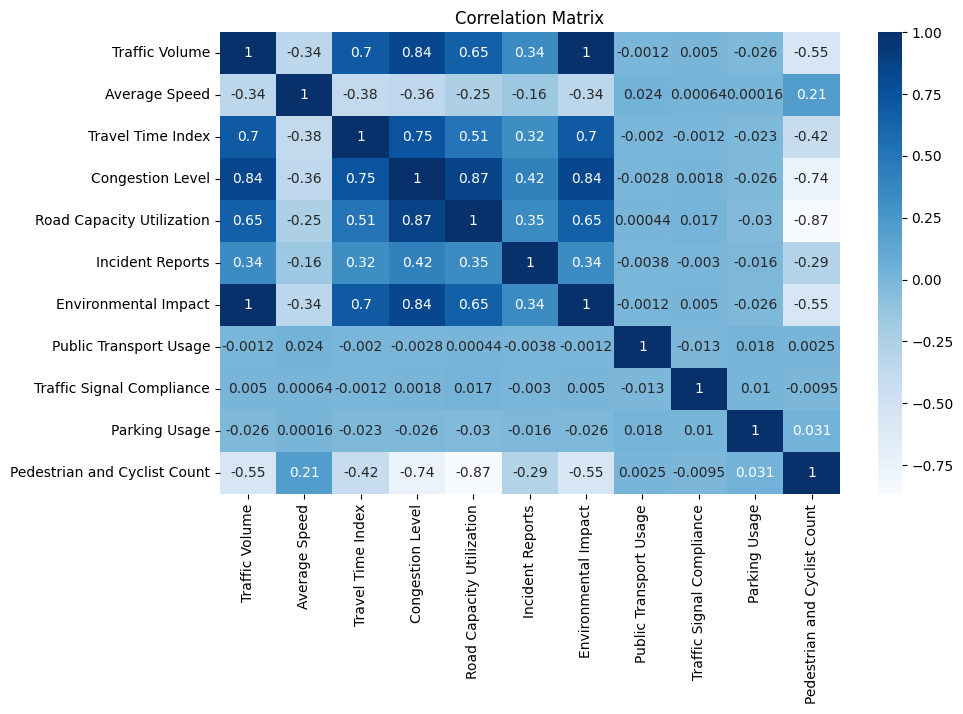

In [9]:
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues')
plt.title("Correlation Matrix")
plt.show()


In [11]:
import plotly.express as px

fig = px.line(df, x='Date', y='Traffic Volume', title='Traffic Volume Trend Over Time')
fig.show()


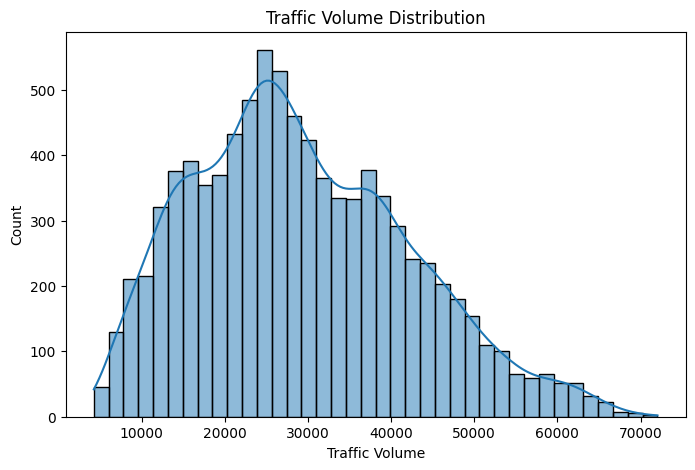

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['Traffic Volume'], kde=True)
plt.title("Traffic Volume Distribution")
plt.show()


In [13]:
df['Date'] = pd.to_datetime(df['Date'])
traffic_ts = df.set_index('Date')['Traffic Volume']
traffic_ts.head()


,Traffic Volume
Date,
2022-01-01,50590
2022-01-01,15043
2022-01-01,38446
2022-01-01,31760
2022-01-01,25379


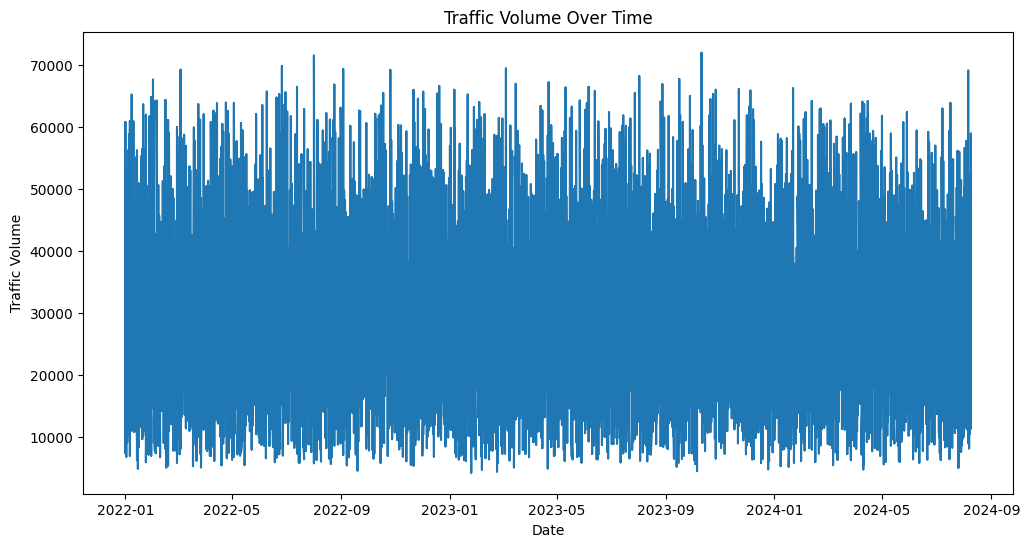

In [14]:
plt.figure(figsize=(12,6))
plt.plot(traffic_ts)
plt.title("Traffic Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Traffic Volume")
plt.show()


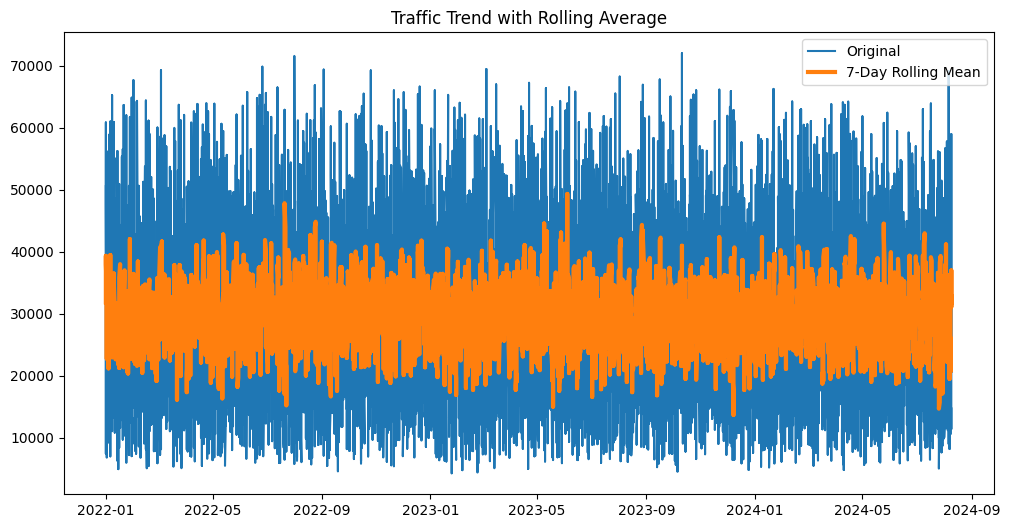

In [15]:
traffic_ts_rolling = traffic_ts.rolling(window=7).mean()

plt.figure(figsize=(12,6))
plt.plot(traffic_ts, label='Original')
plt.plot(traffic_ts_rolling, label='7-Day Rolling Mean', linewidth=3)
plt.title("Traffic Trend with Rolling Average")
plt.legend()
plt.show()


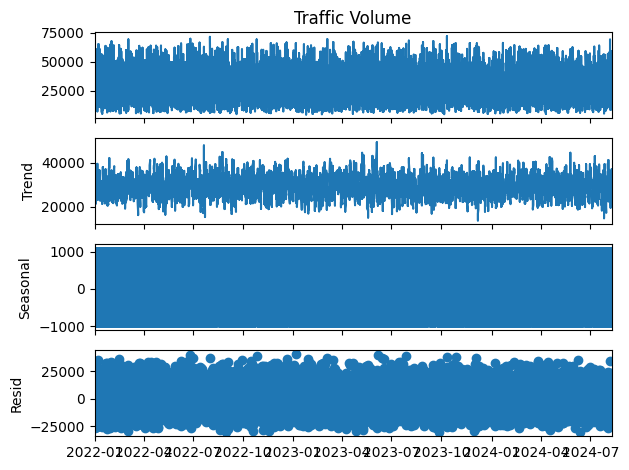

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(traffic_ts, model='additive', period=7)
decomp.plot()
plt.show()


In [18]:
# Assuming traffic_ts is your time series (Date as index, Traffic Volume as values)

train = traffic_ts[:-30]   # all except last 30 days
test = traffic_ts[-30:]    # last 30 days


In [19]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(5,1,2))
model_fit = model.fit()
print(model_fit.summary())



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.



                               SARIMAX Results                                
Dep. Variable:         Traffic Volume   No. Observations:                 8906
Model:                 ARIMA(5, 1, 2)   Log Likelihood              -97027.757
Date:                Wed, 03 Dec 2025   AIC                         194071.513
Time:                        14:23:40   BIC                         194128.268
Sample:                             0   HQIC                        194090.836
                               - 8906                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0159      0.016    -64.035      0.000      -1.047      -0.985
ar.L2         -0.0567      0.018     -3.236      0.001      -0.091      -0.022
ar.L3         -0.0441      0.018     -2.499      0.0

In [23]:
# Make sure 'traffic_ts', 'train', and 'model_fit' exist

model = ARIMA(train, order=(5,1,2))
model_fit = model.fit()

# Generate forecast
forecast = model_fit.forecast(steps=30)

forecast.head()   # to verify it exists


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given w

,predicted_mean
8906,29561.685457
8907,29391.081904
8908,29288.352842
8909,29547.752835
8910,29355.587083


In [24]:
fig = px.line(title="Traffic Volume Forecast - Next 30 Days (ARIMA)")
fig.add_scatter(x=test.index, y=test, name="Actual Traffic")
fig.add_scatter(x=test.index, y=forecast, name="Predicted Traffic")
fig.show()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.



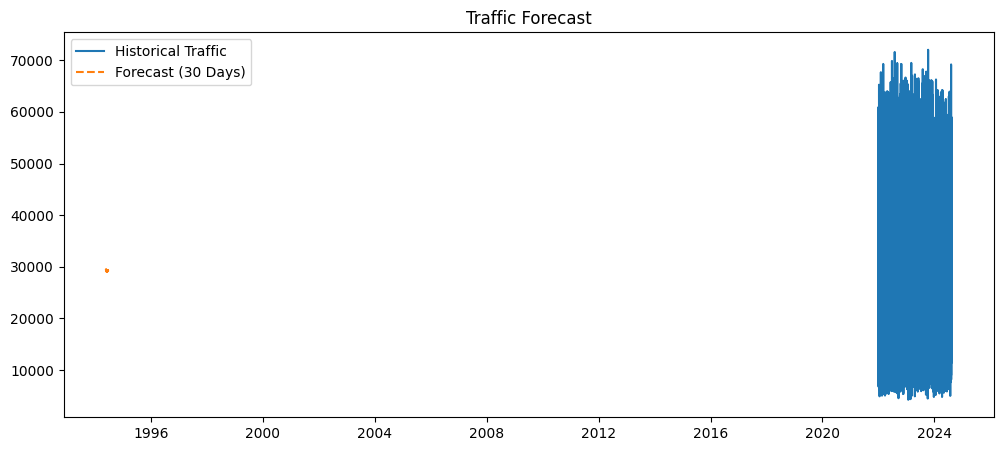

In [25]:
forecast = model_fit.forecast(30)

plt.figure(figsize=(12,5))
plt.plot(traffic_ts, label='Historical Traffic')
plt.plot(forecast, label='Forecast (30 Days)', linestyle='--')
plt.legend()
plt.title("Traffic Forecast")
plt.show()
